# andre_becker_DR3_TP2 (Notebook)

> **Disciplina:** Inteligência Artificial: Classificação [25E3_3]  
> **Aluno:** André Luis Becker  
> **Professor:** Diego da Silva Rodrigues  
> **Data:** 2025-08-25

---

## Introdução — Titanic (SVM como baseline)

Este TP2 utiliza o **dataset do Titanic** para um problema de **classificação binária** (`Survived`: 0/1), construindo um baseline com **Support Vector Machine (SVM)**:
- **Q1:** preparação do dataset e **split 75/25 estratificado**  
- **Q2:** **SVM (núcleo *linear*)** + matriz de confusão e métricas (**Acc/Precision/Recall/F1**)  
- **Q3:** repetição com **núcleos RBF e Sigmoid** + mesmas métricas e matrizes  
- **Q4:** **comparativo** e indicação do **melhor** modelo

**Fonte dos dados:**  
`https://github.com/cassiusf/datasets/raw/refs/heads/main/titanic_data.csv`

**Features (após preparação):** `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`.  
**Remoções (Q1.1):** `PassengerId`, `Name`, `Ticket`, `Cabin`.  
**Limpeza (Q1.2):** eliminação de observações com valores ausentes.  
**Codificação (Q1.3):** `LabelEncoder` em `Embarked` e `Sex`.  
**Escalonamento (Q1.3b):** `StandardScaler` em **todas** as colunas de `X` (baseline).  
**Divisão (Q1.4):** **75/25 estratificado**.

**Stack & Reprodutibilidade:** Python, pandas, scikit-learn, seaborn, matplotlib.


## 1. Carregamento e preparação do dataset _(Q1.1–Q1.4)_

In [ ]:
# Q1 — Carregar, preparar, escalar e dividir 75/25 (estratificado)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from IPython.display import display

# 1.1 — Carregar e remover colunas não usadas
url = "https://github.com/cassiusf/datasets/raw/refs/heads/main/titanic_data.csv"
df = pd.read_csv(url)
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")

# 1.2 — Remover linhas com NAs (baseline sem imputação)
df = df.dropna().reset_index(drop=True)

# 1.3 — Codificação simples (nominais) com LabelEncoder
le_sex = LabelEncoder(); le_emb = LabelEncoder()
df["Sex"] = le_sex.fit_transform(df["Sex"].astype(str))
df["Embarked"] = le_emb.fit_transform(df["Embarked"].astype(str))

# Mostra as 10 primeiras linhas do dataset pronto
display(df.head(10))

# 1.4 — Split 75/25 com estratificação no alvo
X = df.drop(columns=["Survived"])
y = df["Survived"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# 1.3b — Escalonar features (SVM é sensível à escala)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Saída clara do split 75/25 (contagens + percentuais exatos)
n_total = len(df)
n_tr, n_te = len(X_train), len(X_test)
pct_train = 100 * n_tr / n_total
pct_test = 100 * n_te / n_total
print(f"Tamanho total: {n_total} | Treino: {n_tr} ({pct_train:.1f}%) | Teste: {n_te} ({pct_test:.1f}%)")
print("Colunas finais:", list(df.columns))


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
5,0,1,1,54.0,0,0,51.8625,2
6,0,3,1,2.0,3,1,21.0750,2
7,1,3,0,27.0,0,2,11.1333,2
8,1,2,0,14.0,1,0,30.0708,0
9,1,3,0,4.0,1,1,16.7000,2


Tamanho total: 712 | Treino: 534 (75.0%) | Teste: 178 (25.0%)
Colunas finais: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


## 2. SVM com núcleo **linear** — métricas e matriz de confusão _(Q2)_

,Previsto: Não Sobreviveu,Previsto: Sobreviveu
Verdadeiro: Não Sobreviveu,89,17
Verdadeiro: Sobreviveu,23,49


,precision,recall,f1-score,support
Não Sobreviveu,0.795,0.840,0.817,106.000
Sobreviveu,0.742,0.681,0.710,72.000
accuracy,0.775,0.775,0.775,0.775
macro avg,0.769,0.760,0.763,178.000
weighted avg,0.774,0.775,0.773,178.000


[SVM Linear] TN=89  FP=17  FN=23  TP=49
[SVM Linear] Acurácia=0.775  Precision=0.742  Recall=0.681  F1=0.710


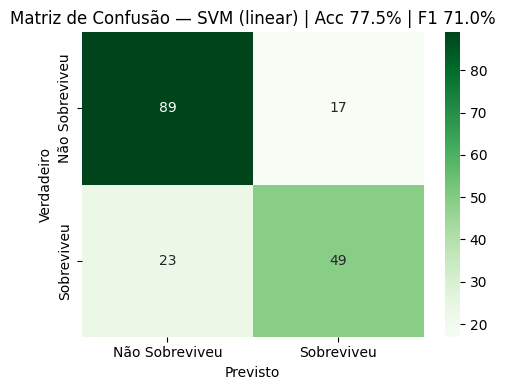

In [ ]:
# Q2 — SVM (linear) + matriz de confusão e métricas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
from IPython.display import display

# Treino (núcleo linear)
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train_scaled, y_train)

# Predições
y_pred_lin = svm_linear.predict(X_test_scaled)

# Matriz de confusão + métricas
cm_lin = confusion_matrix(y_test, y_pred_lin, labels=[0,1])
TN, FP, FN, TP = cm_lin.ravel()
acc  = accuracy_score(y_test, y_pred_lin)
prec = precision_score(y_test, y_pred_lin, zero_division=0)
rec  = recall_score(y_test, y_pred_lin, zero_division=0)
f1   = f1_score(y_test, y_pred_lin, zero_division=0)

# Exibição em DataFrame (legível)
df_cm_lin = pd.DataFrame(
    cm_lin,
    index=["Verdadeiro: Não Sobreviveu","Verdadeiro: Sobreviveu"],
    columns=["Previsto: Não Sobreviveu","Previsto: Sobreviveu"]
)
display(df_cm_lin)

report_lin = classification_report(
    y_test, y_pred_lin,
    target_names=["Não Sobreviveu", "Sobreviveu"],
    output_dict=True
)
display(pd.DataFrame(report_lin).T.round(3))

print(f"[SVM Linear] TN={TN}  FP={FP}  FN={FN}  TP={TP}")
print(f"[SVM Linear] Acurácia={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")

# Heatmap da matriz de confusão (salvando figura)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lin, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Não Sobreviveu", "Sobreviveu"],
            yticklabels=["Não Sobreviveu", "Sobreviveu"])
plt.xlabel("Previsto"); plt.ylabel("Verdadeiro")
plt.title(f"Matriz de Confusão — SVM (linear) | Acc {100*acc:.1f}% | F1 {100*f1:.1f}%")
plt.tight_layout()
plt.savefig("q2_matriz_confusao_svm_linear.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. SVM com núcleos **RBF** e **Sigmoid** — métricas e matrizes _(Q3)_

,Previsto: Não Sobreviveu,Previsto: Sobreviveu
Verdadeiro: Não Sobreviveu,92,14
Verdadeiro: Sobreviveu,25,47


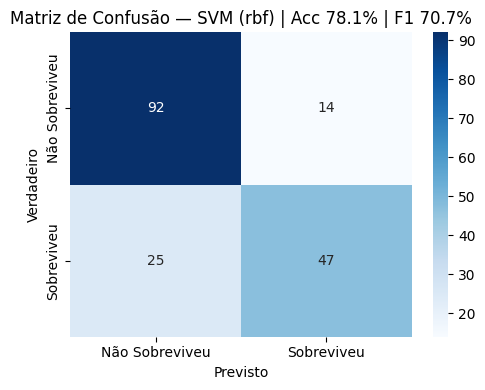

,Previsto: Não Sobreviveu,Previsto: Sobreviveu
Verdadeiro: Não Sobreviveu,89,17
Verdadeiro: Sobreviveu,25,47


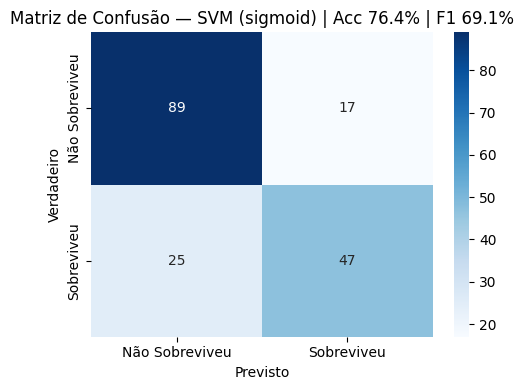

,acc,prec,rec,f1,TN,FP,FN,TP
kernel,,,,,,,,
rbf,0.781,0.770,0.653,0.707,92,14,25,47
sigmoid,0.764,0.734,0.653,0.691,89,17,25,47


In [ ]:
# Q3 — Repetição com RBF e Sigmoid
from collections import OrderedDict

resultados = []
for kernel in ["rbf", "sigmoid"]:
    clf = SVC(kernel=kernel)
    clf.fit(X_train_scaled, y_train)
    y_hat = clf.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_hat, labels=[0,1])
    acc  = accuracy_score(y_test, y_hat)
    prec = precision_score(y_test, y_hat, zero_division=0)
    rec  = recall_score(y_test, y_hat, zero_division=0)
    f1   = f1_score(y_test, y_hat, zero_division=0)

    # DataFrame da matriz de confusão
    df_cm = pd.DataFrame(
        cm,
        index=["Verdadeiro: Não Sobreviveu","Verdadeiro: Sobreviveu"],
        columns=["Previsto: Não Sobreviveu","Previsto: Sobreviveu"]
    )
    display(df_cm)

    # Heatmap da matriz de confusão (salva figura por kernel)
    import matplotlib.pyplot as plt, seaborn as sns
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Não Sobreviveu", "Sobreviveu"],
                yticklabels=["Não Sobreviveu", "Sobreviveu"])
    plt.xlabel("Previsto"); plt.ylabel("Verdadeiro")
    plt.title(f"Matriz de Confusão — SVM ({kernel}) | Acc {100*acc:.1f}% | F1 {100*f1:.1f}%")
    plt.tight_layout()
    plt.savefig(f"q3_matriz_confusao_svm_{kernel}.png", dpi=150, bbox_inches="tight")
    plt.show()

    resultados.append(OrderedDict(kernel=kernel, acc=acc, prec=prec, rec=rec, f1=f1,
                                  TN=cm[0,0], FP=cm[0,1], FN=cm[1,0], TP=cm[1,1]))

df_res = pd.DataFrame(resultados).set_index("kernel")
display(df_res.round(3))


## 4. Comparativo e melhor modelo _(Q4)_

In [ ]:
# Q4 — Comparativo consolidado entre SVM (linear, rbf, sigmoid) e escolha do melhor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# Métricas do linear (Q2)
y_hat_lin = y_pred_lin
cm_lin = confusion_matrix(y_test, y_hat_lin, labels=[0,1])
acc_lin  = accuracy_score(y_test, y_hat_lin)
prec_lin = precision_score(y_test, y_hat_lin, zero_division=0)
rec_lin  = recall_score(y_test, y_hat_lin, zero_division=0)
f1_lin   = f1_score(y_test, y_hat_lin, zero_division=0)

df_lin = pd.DataFrame([{
    "kernel": "linear", "acc": acc_lin, "prec": prec_lin, "rec": rec_lin, "f1": f1_lin,
    "TN": cm_lin[0,0], "FP": cm_lin[0,1], "FN": cm_lin[1,0], "TP": cm_lin[1,1]
}]).set_index("kernel")

# Concatena com resultados RBF/Sigmoid do Q3
df_comp = pd.concat([df_lin, df_res], axis=0)
display(df_comp.round(3))

# Critério: maior F1 (desempate por Acc)
df_sorted = df_comp.sort_values(["f1", "acc"], ascending=False)
best_kernel = df_sorted.index[0]
best_row = df_sorted.iloc[0]

print("\nResumo: melhor kernel segundo F1 (desempate por Acc):")
print(f"Melhor = {best_kernel.upper()} | F1={best_row['f1']:.3f} | Acc={best_row['acc']:.3f} | "
      f"Precision={best_row['prec']:.3f} | Recall={best_row['rec']:.3f}")


,acc,prec,rec,f1,TN,FP,FN,TP
kernel,,,,,,,,
linear,0.775,0.742,0.681,0.710,89,17,23,49
rbf,0.781,0.770,0.653,0.707,92,14,25,47
sigmoid,0.764,0.734,0.653,0.691,89,17,25,47



Resumo: melhor kernel segundo F1 (desempate por Acc):
Melhor = LINEAR | F1=0.710 | Acc=0.775 | Precision=0.742 | Recall=0.681


## Q4 — Comparação dos kernels (linear, RBF e sigmoid) e escolha do melhor

Executei o SVM com três núcleos e comparei **matriz de confusão** e **métricas** no mesmo *holdout* 75/25 (com *standard scaling*).

**Resultados obtidos:**
- **Linear:** TN=89, FP=17, FN=23, TP=49 → **Acc=0.775**, **Prec=0.742**, **Recall=0.681**, **F1=0.710**
- **RBF:** TN=92, FP=14, FN=25, TP=47 → **Acc=0.781**, **Prec=0.770**, **Recall=0.653**, **F1=0.707**
- **Sigmoid:** TN=89, FP=17, FN=25, TP=47 → **Acc=0.764**, **Prec=0.734**, **Recall=0.653**, **F1=0.691**

**Leitura rápida:**
- O **RBF** foi o mais “conservador” nas positivas (**FP=14**, menor que o linear), elevando a **Precisão (0.770)** e a **Acurácia (0.781)**. Em contrapartida, aumentou **FN (25)** e reduziu o **Recall (0.653)**.
- O **linear** recuperou um pouco mais dos sobreviventes (**FN=23**, **Recall=0.681**), com **Precisão=0.742**. No equilíbrio entre precisão e recall, o **F1 do linear (0.710)** ficou levemente **acima** do RBF (0.707).
- O **sigmoid** manteve-se consistente, porém abaixo dos dois anteriores em **F1 (0.691)** e **Acurácia (0.764)**, o que é comum desse kernel para esse tipo de dado.

**Conclusão e recomendação:**  
Adotei o **F1-score** como critério principal (por equilibrar *precision* e *recall*). Pelo **F1**, o **melhor kernel foi o linear (0.710)**, seguido de muito perto pelo **RBF (0.707)**.  
Se a prioridade for **não perder sobreviventes** (minimizar **FN** → maior **recall**), eu **prefiro o linear**. Se a prioridade for **confiar mais nas positivas** (minimizar **FP** → maior **precision**), o **RBF** é uma boa alternativa. O **sigmoid** não trouxe ganhos neste conjunto.

> **Resumo:** escolho o **SVM com kernel linear** como melhor modelo do experimento, por apresentar **maior F1** e um bom compromisso entre captar positivos e evitar alarmes falsos, mantendo a solução simples e estável.


---

### Checklist de Rúbricas (R.2)

- **R.2.1 — SVM linear executado após preparação do dataset (75/25 estratificado):** ✅  
- **R.2.2 — Métricas (Acc/Precision/Recall/F1) + Matriz de Confusão do SVM linear:** ✅  
- **R.2.3 — Reexecução com núcleos RBF e Sigmoid + mesmas métricas e matrizes:** ✅  
- **R.2.4 — Resumo comparativo e indicação do melhor modelo:** ✅  

> Observação: as métricas exatas dependem da execução. O notebook imprime **tabelas** e salva **heatmaps** das matrizes de confusão.
